# Tally Value Change During Depletion Simulation

This example simulates the variation of a tally responce as a function of time. This particular tally is the tritium breeding ratio and this tends to decrease over time as the lithium gets burnt up by neutron irradiation


First import OpenMC and configure the nuclear data paths

In [1]:
# remove any old files
!rm settings.xm model.xml materials.xml geometry.xml settings.xml

import openmc
import openmc.deplete
import math
from pathlib import Path
# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'
# This chain file was downloaded using the download_endf_chain script that is included in the openmc_data package https://github.com/openmc-data-storage/openmc_data\n",
# this file tells openmc the decay paths between isotopes including probabilities of different routes and half lives
# To download this xml file you can run these commands
# pip install openmc_data
# download_endf_chain -d nuclear_data -r b8.0
openmc.config['chain_file'] = Path.home() / 'nuclear_data' / 'chain-endf-b8.0.xml'

rm: cannot remove 'settings.xm': No such file or directory
rm: cannot remove 'model.xml': No such file or directory


In [2]:
# MATERIALS

mats = openmc.Materials()

# makes a simple material from Iron
breeding_material = openmc.Material() 
breeding_material.add_elements_from_formula('Li4SiO4')
breeding_material.set_density('g/cm3', 2.5)

lithium_orthosilicate_radius = 250
breeding_material.volume = (4/3) * math.pi * lithium_orthosilicate_radius**3 # a volume is needed so openmc can find the number of atoms in the cell/material
breeding_material.depletable = True  # depletable = True is needed to tell openmc to update the material with each time step

materials = openmc.Materials([breeding_material])
materials.export_to_xml()


# GEOMETRY

# surfaces
sph1 = openmc.Sphere(r=lithium_orthosilicate_radius, boundary_type='vacuum')

# cells
shield_cell = openmc.Cell(region=-sph1)
shield_cell.fill = breeding_material
shield_cell.volume = (4/3) * math.pi * sph1.r**3

geometry = openmc.Geometry([shield_cell])

This section defines the neutron source term to use and the settings

In [3]:
# creates a 14MeV neutron point source
source = openmc.IndependentSource()
source.space = openmc.stats.Point((0, 0, 0))
source.angle = openmc.stats.Isotropic()
source.energy = openmc.stats.Discrete([14e6], [1])
source.particles = 'neutron'

# SETTINGS

# Instantiate a Settings object
settings = openmc.Settings()
settings.batches = 2
settings.inactive = 0
settings.particles = 5000
settings.source = source
settings.run_mode = 'fixed source'


tallies = openmc.Tallies()

# added a cell tally for tritium production
cell_filter = openmc.CellFilter(shield_cell)
tbr_tally = openmc.Tally(name='TBR')
tbr_tally.filters = [cell_filter]
tbr_tally.scores = ['(n,Xt)']  # Where X is a wildcard character, this catches any tritium production
tallies.append(tbr_tally)

geometry.export_to_xml()
settings.export_to_xml()
tallies.export_to_xml()
materials.export_to_xml()
model = openmc.model.Model(geometry, materials, settings, tallies)

This is the depltion specific part of the model setup.
Here we:

    specify the chain file, this tells openmc the decay paths between isotopes including probabilities of different routes and half lives
    
    set the time steps and corresponding source rates 

In [4]:
operator = openmc.deplete.CoupledOperator(
    model=model,
    normalization_mode="source-rate",  # set for fixed source simulation, otherwise defaults to fission simulation
    reduce_chain_level=5
)

time_steps = [365*24*60*60] * 5 # 5 steps of 5 years in seconds
source_rates = [1e9]*5 # 1GW

integrator = openmc.deplete.PredictorIntegrator(operator, time_steps, source_rates)

integrator.integrate()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading materials XML file...
 Reading geometry XML file...
 Reading Li6 from /home/jon/nuclear_data/neutron/Li6.h5
 Reading Li7 from /home/jon/nuclear_data/neutron/Li7.h5
 Reading O16 from /home/jon/nuclear_data/neutron/O16.h5
 Reading O17 from /home/jon/nuclear_data/neutron/O17.h5


 Reading O18 from /home/jon/nuclear_data/neutron/O18.h5
 Reading Si28 from /home/jon/nuclear_data/neutron/Si28.h5


 Reading Si29 from /home/jon/nuclear_data/neutron/Si29.h5


 Reading Si30 from /home/jon/nuclear_data/neutron/Si30.h5
 Minimum neutron data temperature: 294.0 K
 Maximum neutron data temperature: 294.0 K
 Reading tallies XML file...
 Preparing distributed cell instances...
 Reading plot XML file...
 Writing summary.h5 file...
[openmc.deplete] t=0.0 s, dt=31536000 s, source=1000000000.0
 Reading H1 from /home/jon/nuclear_data/neutron/H1.h5
 Reading H2 from /home/jon/nuclear_data/neutron/H2.h5
 Reading H3 from /home/jon/nuclear_data/neutron/H3.h5


...

 Simulating batch 2


 Creating state point statepoint.2.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 0.0000e+00 seconds
   Reading cross sections          = 0.0000e+00 seconds
 Total time in simulation          = 2.5519e+00 seconds
   Time in transport only          = 2.5171e+00 seconds
   Time in active batches          = 2.5519e+00 seconds
   Time accumulating tallies       = 1.4792e-02 seconds
   Time writing statepoints        = 1.9872e-02 seconds
 Total time for finalization       = 3.8021e-04 seconds
 Total time elapsed                = 2.5801e+00 seconds
 Calculation Rate (active)         = 3918.72 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.00000 +/- 0.00000

 Creating state point openmc_simulation_n4.h5...


[openmc.deplete] t=157680000.0 (final operator evaluation)
 Maximum neutron transport energy: 20000000.0 eV for Li6

 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1


 Simulating batch 2


 Creating state point statepoint.2.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 0.0000e+00 seconds
   Reading cross sections          = 0.0000e+00 seconds
 Total time in simulation          = 2.5518e+00 seconds
   Time in transport only          = 2.5132e+00 seconds
   Time in active batches          = 2.5518e+00 seconds
   Time accumulating tallies       = 2.3809e-04 seconds
   Time writing statepoints        = 3.8351e-02 seconds
 Total time for finalization       = 4.2964e-04 seconds
 Total time elapsed                = 2.5828e+00 seconds
 Calculation Rate (active)         = 3918.75 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.00000 +/- 0.00000

 Creating state point openmc_simulation_n5.h5...


Access the TBR tally at each depletion time step, to observe the TBR decreasing as a function of time the simulation needs to be run with around 50000 particles

In [5]:
for counter in [0,1,2,3,4,5]:
    sp = openmc.StatePoint(f'openmc_simulation_n{counter}.h5')
    tbr_tally = sp.get_tally(name='TBR')
    print(f'depletion step {counter} TBR={tbr_tally.mean.sum()}')

depletion step 0 TBR=1.017648677915861
depletion step 1 TBR=1.0599517005046606
depletion step 2 TBR=1.0413439227976102
depletion step 3 TBR=1.026900582980184
depletion step 4 TBR=1.0257668396398398
depletion step 5 TBR=1.0316594159536596


Certain reations are also available in the depletion results file. 

For example you can access the rate of n,gamma reactions at each time step

In [6]:
results = openmc.deplete.ResultsList.from_hdf5("depletion_results.h5")

times, number_of_n_gamma_reactions = results.get_reaction_rate(breeding_material, 'Li6', '(n,gamma)')

/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/deplete/results.py:94: FutureWarning: The ResultsList.from_hdf5(...) method is no longer necessary and will be removed in a future version of OpenMC. Use Results(...) instead.
  warn(


Then we can plot the changing reaction rate as a function of time steps

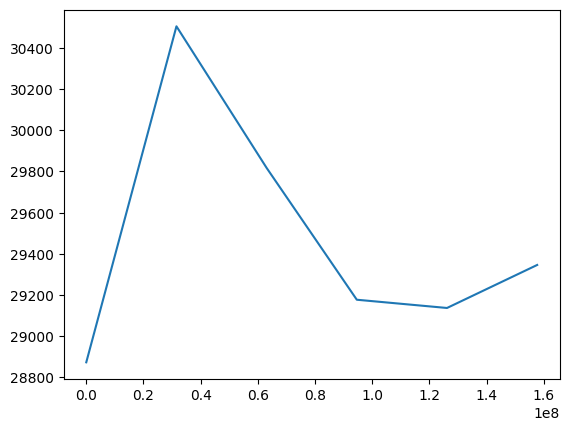

In [7]:
import matplotlib.pyplot as plt
plt.plot(times, number_of_n_gamma_reactions)
plt.show()